In [101]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
saga_satellites = Table.read('https://sagasurvey.org/data/saga-dr3-tableC3.txt', format='ascii.mrt')
saga_hosts = Table.read('https://sagasurvey.org/data/saga-dr3-tableC1.txt', format='ascii.mrt')

In [102]:
host_id = saga_satellites["HOSTID"]
host_names = []
for i in range(0,len(host_id)):
    print("Iteration", i)
    curr = host_id[i]
    if i == 0:
        host_names.append(curr)
    else:
        if curr == host_names[-1]:
            print(".not a new name")
            pass
        else:
            print(".a new name!")
            if curr in host_names:
                print("..found already in list!")
                pass
            else:
                print("...really a new name!!!")
                host_names.append(curr)
    print("Number of unique galaxies:", len(host_names))

Iteration 0
Number of unique galaxies: 1
Iteration 1
.a new name!
...really a new name!!!
Number of unique galaxies: 2
Iteration 2
.not a new name
Number of unique galaxies: 2
Iteration 3
.a new name!
..found already in list!
Number of unique galaxies: 2
Iteration 4
.a new name!
..found already in list!
Number of unique galaxies: 2
Iteration 5
.a new name!
..found already in list!
Number of unique galaxies: 2
Iteration 6
.not a new name
Number of unique galaxies: 2
Iteration 7
.not a new name
Number of unique galaxies: 2
Iteration 8
.not a new name
Number of unique galaxies: 2
Iteration 9
.a new name!
...really a new name!!!
Number of unique galaxies: 3
Iteration 10
.not a new name
Number of unique galaxies: 3
Iteration 11
.a new name!
...really a new name!!!
Number of unique galaxies: 4
Iteration 12
.not a new name
Number of unique galaxies: 4
Iteration 13
.not a new name
Number of unique galaxies: 4
Iteration 14
.not a new name
Number of unique galaxies: 4
Iteration 15
.not a new nam

In [103]:
print(saga_hosts)

   Name      HOSTID   PGC     RAdeg    ... nsat-GSc nsat-GSPc  log(M*)-1s 
                               deg     ...                    dex(solMass)
---------- --------- ----- ----------- ... -------- --------- ------------
ESO079-003   pgc1952  1952    8.008776 ...        5         5        9.075
ESO121-026  pgc18880 18880   95.411976 ...        2         2        8.299
ESO287-013  pgc66669 66669  320.807952 ...        3         3        8.382
ESO288-025  pgc67782 67782 329.8244415 ...        2         2        8.104
    IC1783   pgc8279  8279   32.525601 ...        1         1        7.273
   NGC0157 nsa127226  2081    8.694936 ...        4         4        8.153
   NGC0514 nsa129387  5139   21.016287 ...        1         1        7.201
   NGC0636 nsa130133  6110  24.7772265 ...        2         3        8.881
   NGC0895 nsa155005  8974   35.401959 ...        5         5        8.044
       ...       ...   ...         ... ...      ...       ...          ...
   NGC7716  nsa61945 7188

In [104]:
print(saga_hosts.colnames)
print(len(saga_hosts))
host_id_direct = saga_hosts["HOSTID"]

['Name', 'HOSTID', 'PGC', 'RAdeg', 'DEdeg', 'HRV', 'Dist', 'DistMod', 'KsMag', 'log(Mhalo)', 'log(MHI)', 'rmag', 'gr', 'sb', 'ba', 'PA', 'Sersic', 'log(M*)', 'log(sfr)', 'HOSTID-MW', 'sep-MW', 'count-MW', 'sep-massive', 'nz-saga', 'nz-total', 'nsat-G', 'nsat-GS', 'nsat-Gc', 'nsat-GSc', 'nsat-GSPc', 'log(M*)-1s']
101


In [105]:
#check if fits with only host list
host_names = np.array(host_names) 
missing = []
for i in host_id_direct: 
    if i in host_names:
        print(i, ":all good")
    else:
        print(i, ":missing!!!")
        missing.append(i)
print(missing)

pgc1952 :all good
pgc18880 :all good
pgc66669 :all good
pgc67782 :all good
pgc8279 :all good
nsa127226 :all good
nsa129387 :all good
nsa130133 :all good
nsa155005 :all good
pgc9747 :all good
nsa132339 :all good
nsa132368 :all good
pgc10330 :all good
nsa133115 :all good
nsa133141 :all good
pgc12342 :all good
nsa133355 :all good
pgc13108 :all good
pgc13166 :all good
pgc16044 :all good
nsa33446 :all good
nsa135296 :all good
nsa135591 :all good
nsa135739 :all good
pgc26034 :all good
nsa47117 :all good
nsa157300 :all good
nsa157374 :all good
nsa32 :all good
nsa85746 :all good
nsa16559 :all good
nsa158901 :all good
nsa159488 :all good
nsa159520 :all good
nsa159593 :all good
nsa139467 :all good
nsa160302 :all good
pgc36304 :all good
nsa140458 :all good
nsa13927 :missing!!!
nsa161174 :all good
nsa3469 :all good
nsa141315 :all good
nsa141465 :all good
nsa14409 :all good
nsa52773 :all good
pgc45643 :all good
nsa163956 :all good
nsa143856 :all good
nsa56434 :all good
nsa94340 :all good
nsa94217 :

In [106]:
def radec_dist_to_cartesian(ra_deg, dec_deg, dist_Mpc):
    """
    Convert RA, Dec, distance to heliocentric Cartesian [Mpc].
    Standard equatorial Cartesian: x toward (0,0), y toward (90,0), z toward N pole
    """
    ra  = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    x = dist_Mpc * np.cos(dec) * np.cos(ra)
    y = dist_Mpc * np.cos(dec) * np.sin(ra)
    z = dist_Mpc * np.sin(dec)
    return np.array([x, y, z])

def host_centred_coords(ra_sat, dec_sat, dist_sat_Mpc,
                        ra_host, dec_host, dist_host_Mpc):
    """
    Satellite position in host-centred Cartesian frame [kpc].

    If dist_sat_Mpc is unknown, pass dist_host_Mpc for the satellite
    (projected distance assumption).
    """
    r_sat  = radec_dist_to_cartesian(ra_sat,  dec_sat,  dist_sat_Mpc)
    r_host = radec_dist_to_cartesian(ra_host, dec_host, dist_host_Mpc)
    
    r_rel_Mpc = r_sat - r_host
    r_rel_kpc = r_rel_Mpc * 1e3

    return r_rel_kpc   # (x, y, z) in kpc, host at origin


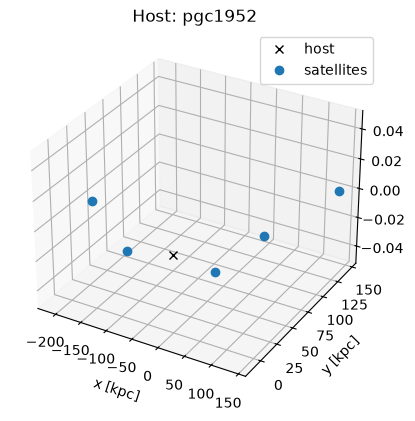

 DVhost
 km / s
-------
-49.475
 123.04
 16.479
-67.462
-37.483


In [107]:
from mpl_toolkits import mplot3d
i = host_names[1]
ra, dec, proj = saga_satellites[saga_satellites["HOSTID"] == i]["RAdeg"], saga_satellites[saga_satellites["HOSTID"] == i]["DEdeg"], saga_satellites[saga_satellites["HOSTID"] == i]["Rhost"]
ra_h, dec_h, dist = saga_hosts[saga_hosts["HOSTID"] == i]["RAdeg"], saga_hosts[saga_hosts["HOSTID"] == i]["DEdeg"], saga_hosts[saga_hosts["HOSTID"] == i]["Dist"]
    
vrel = saga_satellites[saga_satellites["HOSTID"] == i]["DVhost"]

fig = plt.figure()
ax = plt.axes(projection='3d')

x,y,z = host_centred_coords(ra, dec, dist, ra_h, dec_h, dist)
r = np.sqrt(x**2 + y**2 + z**2)
ax.plot3D(0, 0 , 'kx', label ="host")
ax.plot3D(x, y , 'o', label="satellites")
plt.title("Host: " + i)
plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.legend()
plt.show()
print(vrel)

In [108]:
saga_satellites.colnames

['OBJID',
 'HOSTID',
 'PGC',
 'RAdeg',
 'DEdeg',
 'Rhost',
 'rmag',
 'e_rmag',
 'gr',
 'rmag-fiber',
 'sb',
 'ba',
 'PA',
 'Sersic',
 'TELNAME',
 'z',
 'DVhost',
 'log(M*)',
 'EW-Halpha',
 'e_EW-Halpha',
 'log(sfr)Halpha',
 'e_log(sfr)Halpha',
 'NUVmag',
 'e_NUVmag',
 'f_NUVmag',
 'log(sfr)NUV',
 'e_log(sfr)NUV',
 'quenched',
 'log(MHI)',
 'HIsource',
 'flux-Halpha',
 'e_flux-Halpha',
 'flux-Hbeta',
 'e_flux-Hbeta',
 'flux-NII',
 'e_flux-NII',
 'flux-OIII',
 'e_flux-OIII',
 'flux-SII6717',
 'e_flux-SII6717',
 'flux-SII6731',
 'e_flux-SII6731',
 'flux-note',
 'sample']

In [109]:
saga_hosts.colnames

['Name',
 'HOSTID',
 'PGC',
 'RAdeg',
 'DEdeg',
 'HRV',
 'Dist',
 'DistMod',
 'KsMag',
 'log(Mhalo)',
 'log(MHI)',
 'rmag',
 'gr',
 'sb',
 'ba',
 'PA',
 'Sersic',
 'log(M*)',
 'log(sfr)',
 'HOSTID-MW',
 'sep-MW',
 'count-MW',
 'sep-massive',
 'nz-saga',
 'nz-total',
 'nsat-G',
 'nsat-GS',
 'nsat-Gc',
 'nsat-GSc',
 'nsat-GSPc',
 'log(M*)-1s']

In [123]:
def phase_space_coords(ra_sat, dec_sat,
                       ra_host, dec_host, dist_host_Mpc,
                       PA_deg=None):
    """
    Build phase space coordinates for satellite plane correlation.
    
    If PA_plane_deg is given, x-axis is aligned with the satellite
    plane major axis — maximises the position-velocity signal.
    Otherwise uses standard RA/Dec offsets.
    """
    # ── projected position ────────────────────────────────────────────────────
    dra  = (ra_sat - ra_host) * np.cos(np.deg2rad(dec_host))
    ddec =  dec_sat - dec_host
    deg2kpc = dist_host_Mpc * 1e3 * np.deg2rad(1)

    dx = dra  * deg2kpc   # East
    dy = ddec * deg2kpc   # North

    # ── rotate into plane coordinate system if PA known ───────────────────────
    if PA_deg is not None:
        theta = np.deg2rad(90.0 - PA_deg)
        x_rot =  dx * np.cos(theta) + dy * np.sin(theta)   # along major axis
        y_rot = -dx * np.sin(theta) + dy * np.cos(theta) 
    else:
        x_rot, y_rot = dx, dy

    return x_rot, y_rot

from astropy.table import Table, vstack
from astropy import units as u

# ── apply to full satellite table ─────────────────────────────────────────────
results = []
for host_name in host_id_direct:
    host     = saga_hosts[saga_hosts["HOSTID"] == host_name]
    sats     = saga_satellites[saga_satellites["HOSTID"] == host_name]
    
    x, y = phase_space_coords(
        ra_sat       = sats["RAdeg"],
        dec_sat      = sats["DEdeg"],
        ra_host      = host["RAdeg"],
        dec_host     = host["DEdeg"],
        dist_host_Mpc= host["Dist"], 
    )

    # Add the new columns to this satellite subset
    sats = sats.copy()
    sats["x_kpc"] = x
    sats["y_kpc"] = y

    results.append(sats)

# Combine all satellite subsets back into one Astropy Table
pst = vstack(results)
pst['x_kpc'].unit   = u.kpc
pst['y_kpc'].unit  = u.kpc
pst['x_kpc'].description   = "Distance in host-centered frame"
pst['y_kpc'].description  = "Distance in host-centered frame"

new_order = ['Name',
 'Host',
 'RAdeg',
 'DEdeg',
 "x_kpc", 
 "y_kpc",
 'logMs',
 'e_logMs',
 'mu0V',
 'e_mu0V',
  'vrec',
 're',
 'e_re',
 'D_SBF',
 'D_trgb', 
 'Conf',
'Source',]

pst = pst[new_order]
ascii.write(pst, 'saga_ps.mrt',
            format='mrt',
            overwrite=True)
ascii.read('saga_ps.mrt', format='mrt')


KeyError: 'Name'

In [112]:
from astropy.table import join
from astropy.table import Table, MaskedColumn
from astropy.io import ascii
from astropy import units as u
# read your two ascii tables
import pandas as pd

saga_hosts_df = saga_hosts.to_pandas()
saga_sats_df = saga_satellites.to_pandas()

sats_with_host_name = pd.merge(
    saga_sats_df,
    saga_hosts_df[["HOSTID", "Name"]].rename(columns={
        "Name": "Hostname", 
    }),
    on="HOSTID",
    how="left"
)

print(sats_with_host_name)

                  OBJID     HOSTID     PGC       RAdeg      DEdeg    Rhost  \
0    900315730000006229   pgc68312  127631  334.014809 -64.878786  216.512   
1    900316320000001800    pgc1952      -1    8.273681 -64.634944  234.685   
2    900322490000007741    pgc1952    1951    8.004124 -64.389996   80.501   
3    900328120000004044   pgc68312   68196  332.529412 -64.578212  294.065   
4    900328130000003547   pgc68312  322039  333.108968 -64.507180  244.484   
..                  ...        ...     ...         ...        ...      ...   
373  916153850000001950  nsa165707      -1  222.552196  59.155717  131.730   
374  916168650000000255  nsa165980      -1  228.362352  59.701340  157.748   
375  920321890000007158   pgc68312      -1  333.162743 -64.797285   51.775   
376  923591040000004951  nsa150887      -1  348.696491   4.639668   70.840   
377  923605400000002141  nsa150887      -1  348.554564   4.915096  267.207   

       rmag  e_rmag     gr  rmag-fiber  ...  e_flux-NII  flux-O

In [125]:
t_host = Table()
t_host['Name'] = saga_hosts['Name']
t_host['Name'] = np.array(t_host['Name'], dtype=str)
t_host['RAdeg']    = saga_hosts['RAdeg']
t_host['DEdeg']    = saga_hosts['DEdeg']
t_host['Dist']    = saga_hosts['Dist']
t_host['logMs']    = saga_hosts['log(M*)']
t_host['sb']     = saga_hosts['sb']
t_host['ba']     = saga_hosts['ba']
t_host['PA']     = saga_hosts['PA']
t_host['vrec']     = saga_hosts['HRV']
t_host['Sersic']     = saga_hosts['Sersic']
t_host['nsat']    = saga_hosts['nsat-GSPc']
t_host['Source']     = np.full(len(saga_hosts), '2017ApJ...847....4G', dtype='<U20')

# ── units ─────────────────────────────────────────────────────────────────────
t_host['RAdeg'].unit   = u.deg
t_host['DEdeg'].unit   = u.deg
t_host['Dist'].unit = u.Mpc
t_host['vrec'].unit    = u.km/u.s
t_host['sb'].unit    = u.mag/u.arcsec**2
t_host['logMs'].unit   = u.dex(u.Msun)

# ── descriptions ──────────────────────────────────────────────────────────────
t_host['Name'].description    = "Host name"
t_host['RAdeg'].description   = "Right ascension"
t_host['DEdeg'].description   = "Declination"
t_host['Dist'].description = "Distance to Host"
t_host['logMs'].description   = "log10 stellar mass"
t_host['sb'].description    = "Effective surface brightness"
t_host['ba'].description     = "Galaxy axis ratio"
t_host['PA'].description       = "Galaxy position angle"
t_host['vrec'].description    = "Heliocentric recessional velocity "
t_host['nsat'].description = "Number of confirmed satellites"
t_host['Sersic'].description    = "Galactic sersic index from photometry"
t_host['Source'].description   = "Source of the host data"
# ── mask NaN values for MRT writer ───────────────────────────────────────────
for col in t_host.colnames:
    if t_host[col].dtype == float:
        t_host[col] = MaskedColumn(t_host[col], mask=np.isnan(t_host[col]))
        
ascii.write(t_host, 'saga_hosts.mrt',
            format='mrt',
            overwrite=True)

In [133]:

# ── build astropy table ───────────────────────────────────────────────────────
t = Table()
t['Name'] = sats_with_host_name['OBJID']
t['Name'] = np.array(t['Name'], dtype=str)
t['Host'] = sats_with_host_name['Hostname']
t['Host'] = np.array(t['Host'], dtype=str)
t['RAdeg']    = sats_with_host_name['RAdeg']
t['DEdeg']    = sats_with_host_name['DEdeg']
t['logMs']    = sats_with_host_name['log(M*)']
t['sb']     = sats_with_host_name['sb']
t['vrec']     = sats_with_host_name['DVhost']
t['Sersic']     = sats_with_host_name['Sersic']
t["Conf"] = np.ones(len(sats_with_host_name), dtype=float)
t['Source']     = np.full(len(sats_with_host_name), '2017ApJ...847....4G', dtype='<U20')

# ── units ─────────────────────────────────────────────────────────────────────
t['RAdeg'].unit   = u.deg
t['DEdeg'].unit   = u.deg
t['vrec'].unit    = u.km/u.s
t['sb'].unit    = u.mag/u.arcsec**2
t['logMs'].unit   = u.dex(u.Msun)

# ── descriptions ──────────────────────────────────────────────────────────────
t['Name'].description    = "Satellite name"
t['Host'].description    = "Host galaxy"
t['RAdeg'].description   = "Right ascension"
t['DEdeg'].description   = "Declination"
t['logMs'].description   = "log10 stellar mass"
t['sb'].description    = "Effective surface brightness"
t['vrec'].description    = "Difference in heliocentric recessional velocity in relation to host"
t['Sersic'].description    = "Galactic sersic index from photometry"
t['Conf'].description   = "Confirmed (1=confirmed, 0=unconfirmed)"
t['Source'].description   = "Source of the satellite data"

# ── mask NaN values for MRT writer ───────────────────────────────────────────
for col in t.colnames:
    if t[col].dtype == float:
        t[col] = MaskedColumn(t[col], mask=np.isnan(t[col]))

ascii.write(t, 'saga.mrt',
            format='mrt',
            overwrite=True)
table = ascii.read('saga.mrt',format='mrt')
print(table)

       Name           Host       RAdeg    ... Sersic Conf        Source      
                                  deg     ...                                
------------------ ---------- ----------- ... ------ ---- -------------------
900315730000006229    NGC7219 334.0148085 ...  1.185  1.0 2017ApJ...847....4G
900316320000001800 ESO079-003   8.2736807 ...  0.839  1.0 2017ApJ...847....4G
900322490000007741 ESO079-003   8.0041237 ...  1.366  1.0 2017ApJ...847....4G
900328120000004044    NGC7219 332.5294118 ...  1.065  1.0 2017ApJ...847....4G
900328130000003547    NGC7219 333.1089681 ...  1.665  1.0 2017ApJ...847....4G
900328140000005155    NGC7219 333.8210676 ...  0.838  1.0 2017ApJ...847....4G
900335040000000543 ESO079-003   7.9480205 ...    1.0  1.0 2017ApJ...847....4G
900335040000004860 ESO079-003    8.178446 ...   0.91  1.0 2017ApJ...847....4G
900335050000000168 ESO079-003   8.4905916 ...  1.263  1.0 2017ApJ...847....4G
               ...        ...         ... ...    ...  ...       

In [140]:
hostname = np.array(saga_hosts["Name"])

In [150]:
def phase_space_coords(ra_sat, dec_sat,
                       ra_host, dec_host, dist_host_Mpc,
                       PA_deg=None):
    """
    Build phase space coordinates for satellite plane correlation.
    
    If PA_plane_deg is given, x-axis is aligned with the satellite
    plane major axis — maximises the position-velocity signal.
    Otherwise uses standard RA/Dec offsets.
    """
    # ── projected position ────────────────────────────────────────────────────
    dra  = (ra_sat - ra_host) * np.cos(np.deg2rad(dec_host))
    ddec =  dec_sat - dec_host
    deg2kpc = dist_host_Mpc * 1e3 * np.deg2rad(1)

    dx = dra  * deg2kpc   # East
    dy = ddec * deg2kpc   # North

    # ── rotate into plane coordinate system if PA known ───────────────────────
    if PA_deg is not None:
        theta = np.deg2rad(90.0 - PA_deg)
        x_rot =  dx * np.cos(theta) + dy * np.sin(theta)   # along major axis
        y_rot = -dx * np.sin(theta) + dy * np.cos(theta) 
    else:
        x_rot, y_rot = dx, dy

    return x_rot, y_rot

from astropy.table import Table, vstack
from astropy import units as u

# ── apply to full satellite table ─────────────────────────────────────────────
results = []
for host_name in hostname:
    host     = saga_hosts[saga_hosts["Name"] == host_name]
    sats     = table[table["Host"] == host_name]
    
    x, y = phase_space_coords(
        ra_sat       = sats["RAdeg"],
        dec_sat      = sats["DEdeg"],
        ra_host      = host["RAdeg"],
        dec_host     = host["DEdeg"],
        dist_host_Mpc= host["Dist"], 
    )

    # Add the new columns to this satellite subset
    sats = sats.copy()
    sats["x_kpc"] = x
    sats["y_kpc"] = y

    results.append(sats)

# Combine all satellite subsets back into one Astropy Table
pst = vstack(results)
pst['x_kpc'].unit   = u.kpc
pst['y_kpc'].unit  = u.kpc
pst['x_kpc'].description   = "Distance in host-centered frame"
pst['y_kpc'].description  = "Distance in host-centered frame"

new_order = ['Name',
 'Host',
 'RAdeg',
 'DEdeg',
 "x_kpc", 
 "y_kpc",
 'logMs',
 'sb',
  'vrec',
 'Sersic',
 'Conf',
'Source']

pst = pst[new_order]
ascii.write(pst, 'saga_ps.mrt',
            format='mrt',
            overwrite=True)
t = ascii.read('saga_ps.mrt', format='mrt')
print(t)

       Name           Host       RAdeg    ... Sersic Conf        Source      
                                  deg     ...                                
------------------ ---------- ----------- ... ------ ---- -------------------
900316320000001800 ESO079-003   8.2736807 ...  0.839  1.0 2017ApJ...847....4G
900322490000007741 ESO079-003   8.0041237 ...  1.366  1.0 2017ApJ...847....4G
900335040000000543 ESO079-003   7.9480205 ...    1.0  1.0 2017ApJ...847....4G
900335040000004860 ESO079-003    8.178446 ...   0.91  1.0 2017ApJ...847....4G
900335050000000168 ESO079-003   8.4905916 ...  1.263  1.0 2017ApJ...847....4G
900452380000001288 ESO121-026  95.7327552 ...  0.718  1.0 2017ApJ...847....4G
900459690000002830 ESO121-026  95.7757375 ...  0.902  1.0 2017ApJ...847....4G
900946880000002915 ESO287-013 320.0993302 ...  1.472  1.0 2017ApJ...847....4G
900946900000000551 ESO287-013 320.7336053 ...  0.959  1.0 2017ApJ...847....4G
               ...        ...         ... ...    ...  ...       

In [149]:
t1 = ascii.read('elves_ps.mrt', format='mrt')
t2 = ascii.read('saga_ps.mrt', format='mrt')

In [144]:
print("t1 Name dtype:", t1['Name'].dtype, "len:", len(t1))
print("t2 Name dtype:", t2['Name'].dtype, "len:", len(t2))

t2['Name'] = np.array(t2['Name'], dtype=str)

print("t2 Name dtype after cast:", t2['Name'].dtype)

t1 Name dtype: <U11 len: 444
t2 Name dtype: <U18 len: 378
t2 Name dtype after cast: <U18


In [147]:
from astropy.table import vstack
combined = vstack([t1, t2], join_type='outer')
new_order = ['Name',
 'Host',
 'RAdeg',
 'DEdeg',
 "x_kpc",
  "y_kpc",
 'logMs',
 'e_logMs',
 'mu0V',
 'e_mu0V',
 'sb',
 're',
 'e_re',
'Sersic',
 'vrec',
 'D_SBF',
 'D_trgb', 
 'Conf',
'Source',]

combined = combined[new_order]
ascii.write(combined, 'satellite_catalogue.mrt', format='mrt', overwrite=True)
ascii.read('satellite_catalogue.mrt', format='mrt')

Name,Host,RAdeg,DEdeg,x_kpc,y_kpc,logMs,e_logMs,mu0V,e_mu0V,sb,re,e_re,Sersic,vrec,D_SBF,D_trgb,Conf,Source
,,deg,deg,kpc,kpc,dex(solMass),dex(solMass),mag / arcsec2,mag / arcsec2,mag / arcsec2,pc,pc,,km / s,Mpc,Mpc,,
str18,str10,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str19
M33,M31,23.4583,30.6603,130.70302421762935,-144.4188572058902,9.51,0.22,25.46,0.6,--,--,--,--,--,--,--,1.0,2022ApJ...933...47C
NGC205,M31,10.0917,41.6853,-6.0678299867048135,5.670731819362171,8.78,0.22,19.2,--,--,589.7,24.0,--,--,--,--,1.0,2022ApJ...933...47C
M32,M31,10.6708,40.8653,-0.14231402380250732,-5.492394076393564,8.76,0.22,11.1,--,--,110.1,11.7,--,--,--,--,1.0,2022ApJ...933...47C
NGC147,M31,8.3,48.5089,-24.401014153052675,98.56427555384852,8.01,0.22,21.2,--,--,623.4,--,--,--,--,--,1.0,2022ApJ...933...47C
IC10,M31,5.0708,59.3039,-57.44310731037286,245.5227439010231,7.83,0.22,24.6,0.2,--,612.3,--,--,--,--,--,1.0,2022ApJ...933...47C
NGC185,M31,9.7417,48.3375,-9.649129567115457,96.23090997027228,8.05,0.22,20.8,--,--,457.4,--,--,--,--,--,1.0,2022ApJ...933...47C
andVII,M31,351.6292,50.6758,3488.641042711871,128.0635164117914,7.39,0.22,23.2,0.2,--,775.9,22.2,--,--,--,--,1.0,2022ApJ...933...47C
andXXXII,M31,8.9975,51.5597,-17.26399570352003,140.09654931332608,6.98,0.22,26.4,0.8,--,1467.7,271.0,--,--,--,--,1.0,2022ApJ...933...47C


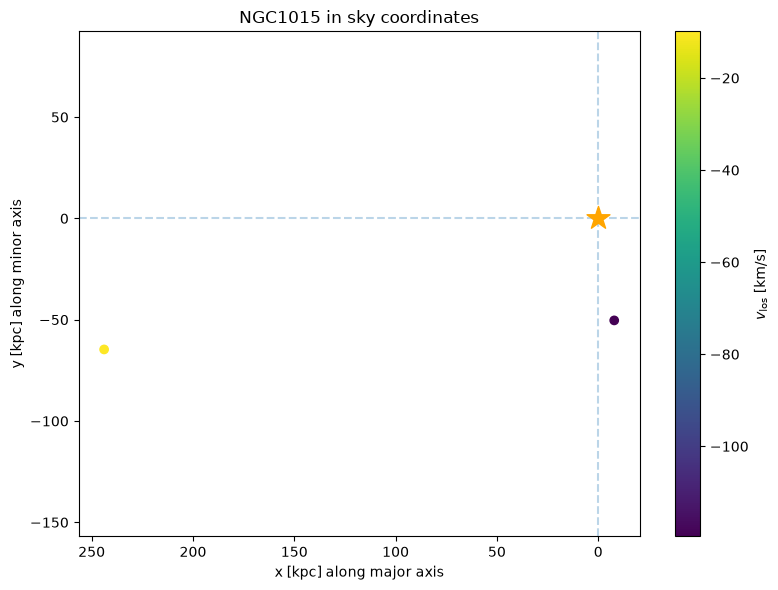

In [156]:
fig, ax = plt.subplots(figsize=(8,6))
t = ascii.read('saga_ps.mrt', format='mrt')

hostid = hostname[10]
h    = t[t["Host"] == hostid]

sc = plt.scatter(h["x_kpc"], h["y_kpc"], c = h["vrec"])
plt.scatter(0, 0, marker="*", s=300, color="orange", zorder=4)
plt.axhline(0, ls="--", alpha=0.3)
plt.axvline(0, ls="--", alpha=0.3)
plt.colorbar(sc, ax=ax, label="$v_{\\rm los}$ [km/s]")
ax.invert_xaxis()
plt.xlabel("x [kpc] along major axis")
plt.ylabel("y [kpc] along minor axis")
plt.title(f"{hostid} in sky coordinates")
plt.axis("equal")
plt.tight_layout()
plt.show()